# Exploratory Data Analysis

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
pd.set_option('display.max_columns',None)
sns.set_theme(style='whitegrid')

In [5]:
df_train = pd.read_csv('data/raw/train.csv')

In [6]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## Analyzing Sale Price

In [7]:
# descriptive stats 'SalePrice'
df_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

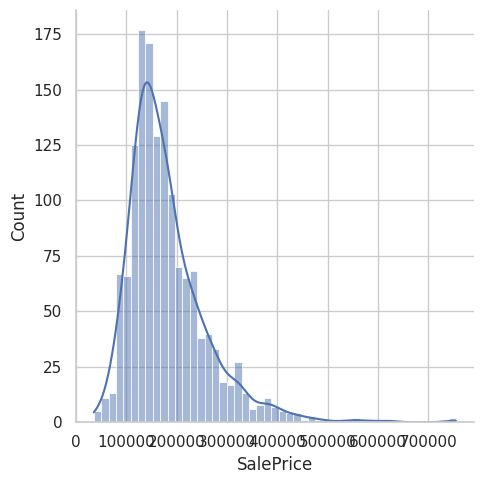

In [8]:
sns.displot(data = df_train , x = 'SalePrice' , kde = True)


In [9]:
# skewness and kurtosis
print(f'Skewness : {df_train['SalePrice'].skew()}')
print(f'Kurtosis : {df_train['SalePrice'].kurtosis()}')

Skewness : 1.8828757597682129
Kurtosis : 6.536281860064529


## Relationship with numerical variables

(0.0, 800000.0)

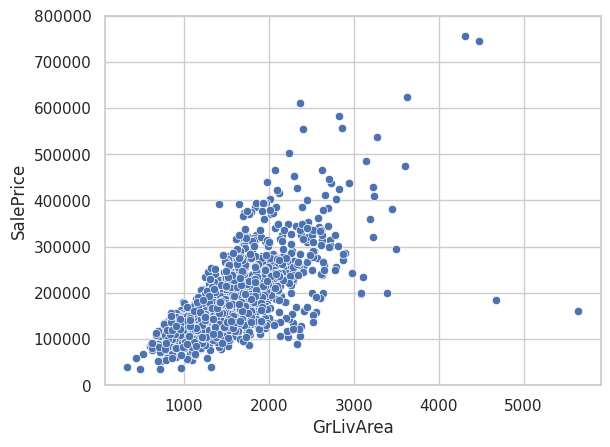

In [10]:
feature = 'GrLivArea'
sns.scatterplot(data = df_train , x=feature , y = 'SalePrice')
plt.ylim((0,800000))

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

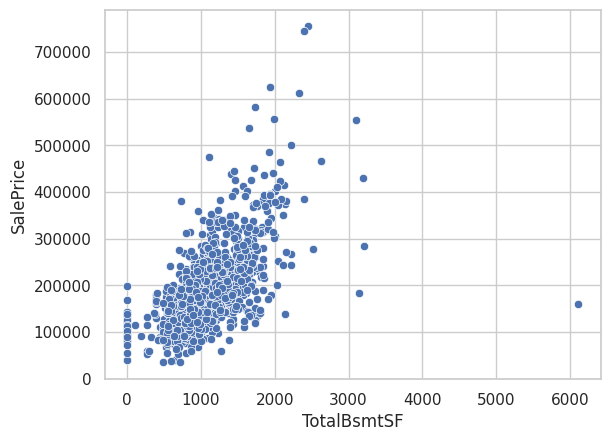

In [11]:
feature = 'TotalBsmtSF'
sns.scatterplot(data = df_train , x = feature , y = 'SalePrice')

## Relationship with Categorical features

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

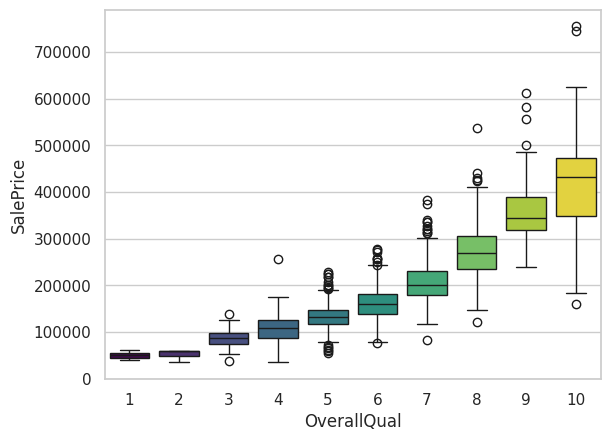

In [12]:
feature = 'OverallQual'
sns.boxplot(data = df_train , x = feature , y = 'SalePrice' , hue=feature , legend=False , palette='viridis')

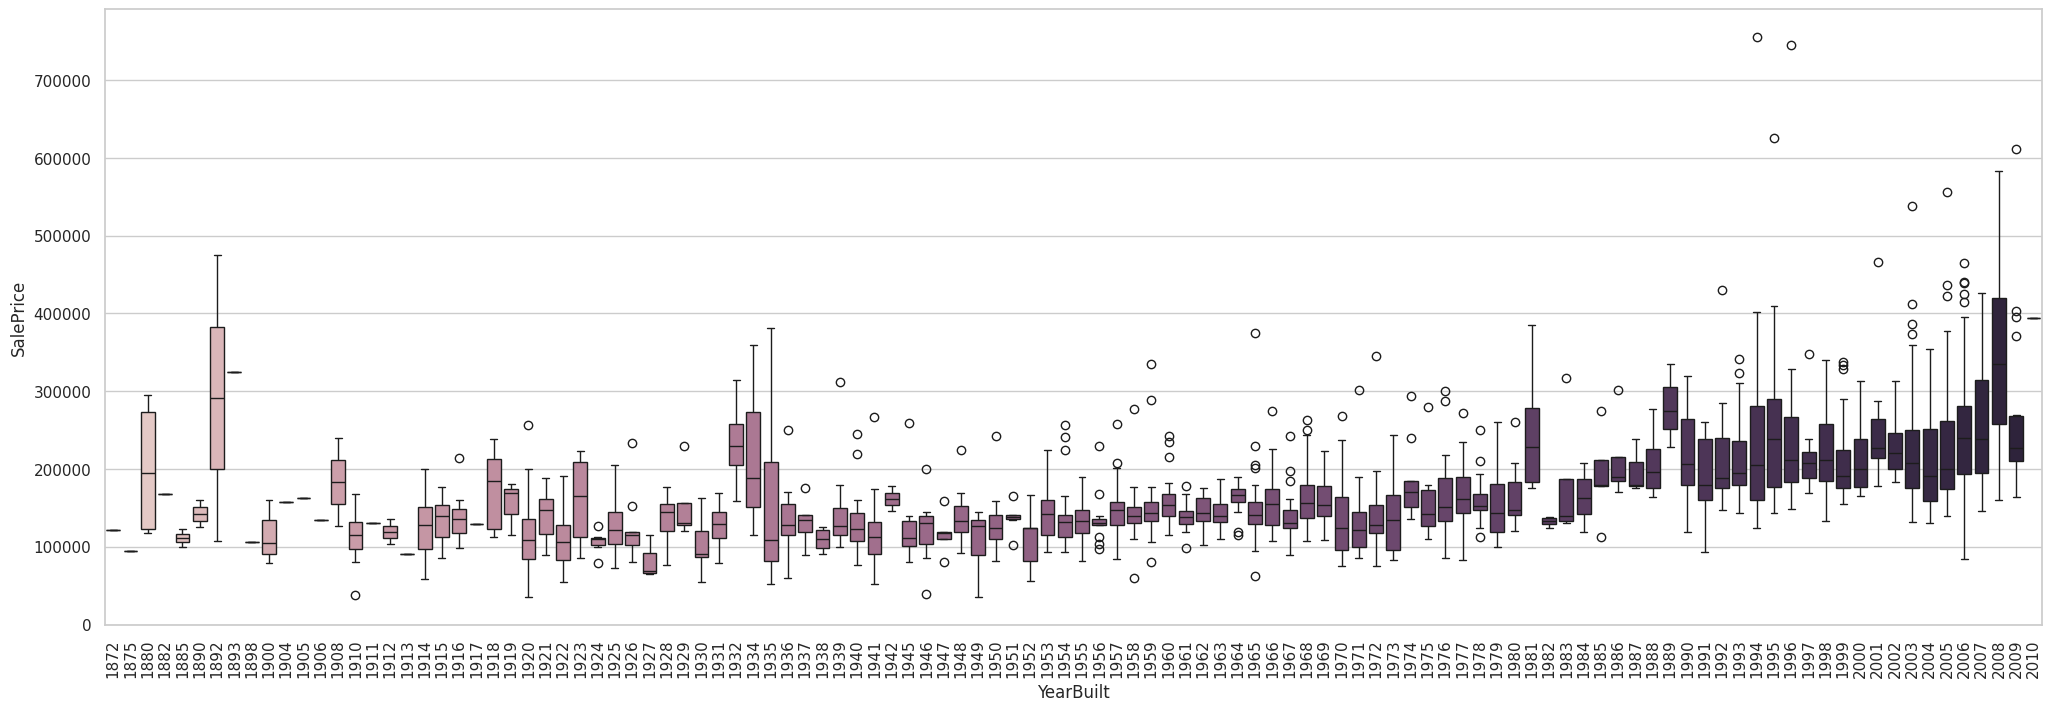

In [13]:
feature = 'YearBuilt'
plt.figure(figsize=(25,8))
sns.boxplot(data =df_train , x = feature , y = 'SalePrice' , hue = feature , legend=False);
plt.xticks(rotation = 90);

In [14]:
set(df_train.dtypes.values)

{dtype('int64'), dtype('float64'), dtype('O')}

In [15]:
numeric_features = df_train.select_dtypes(include=['float64' , 'int64'])

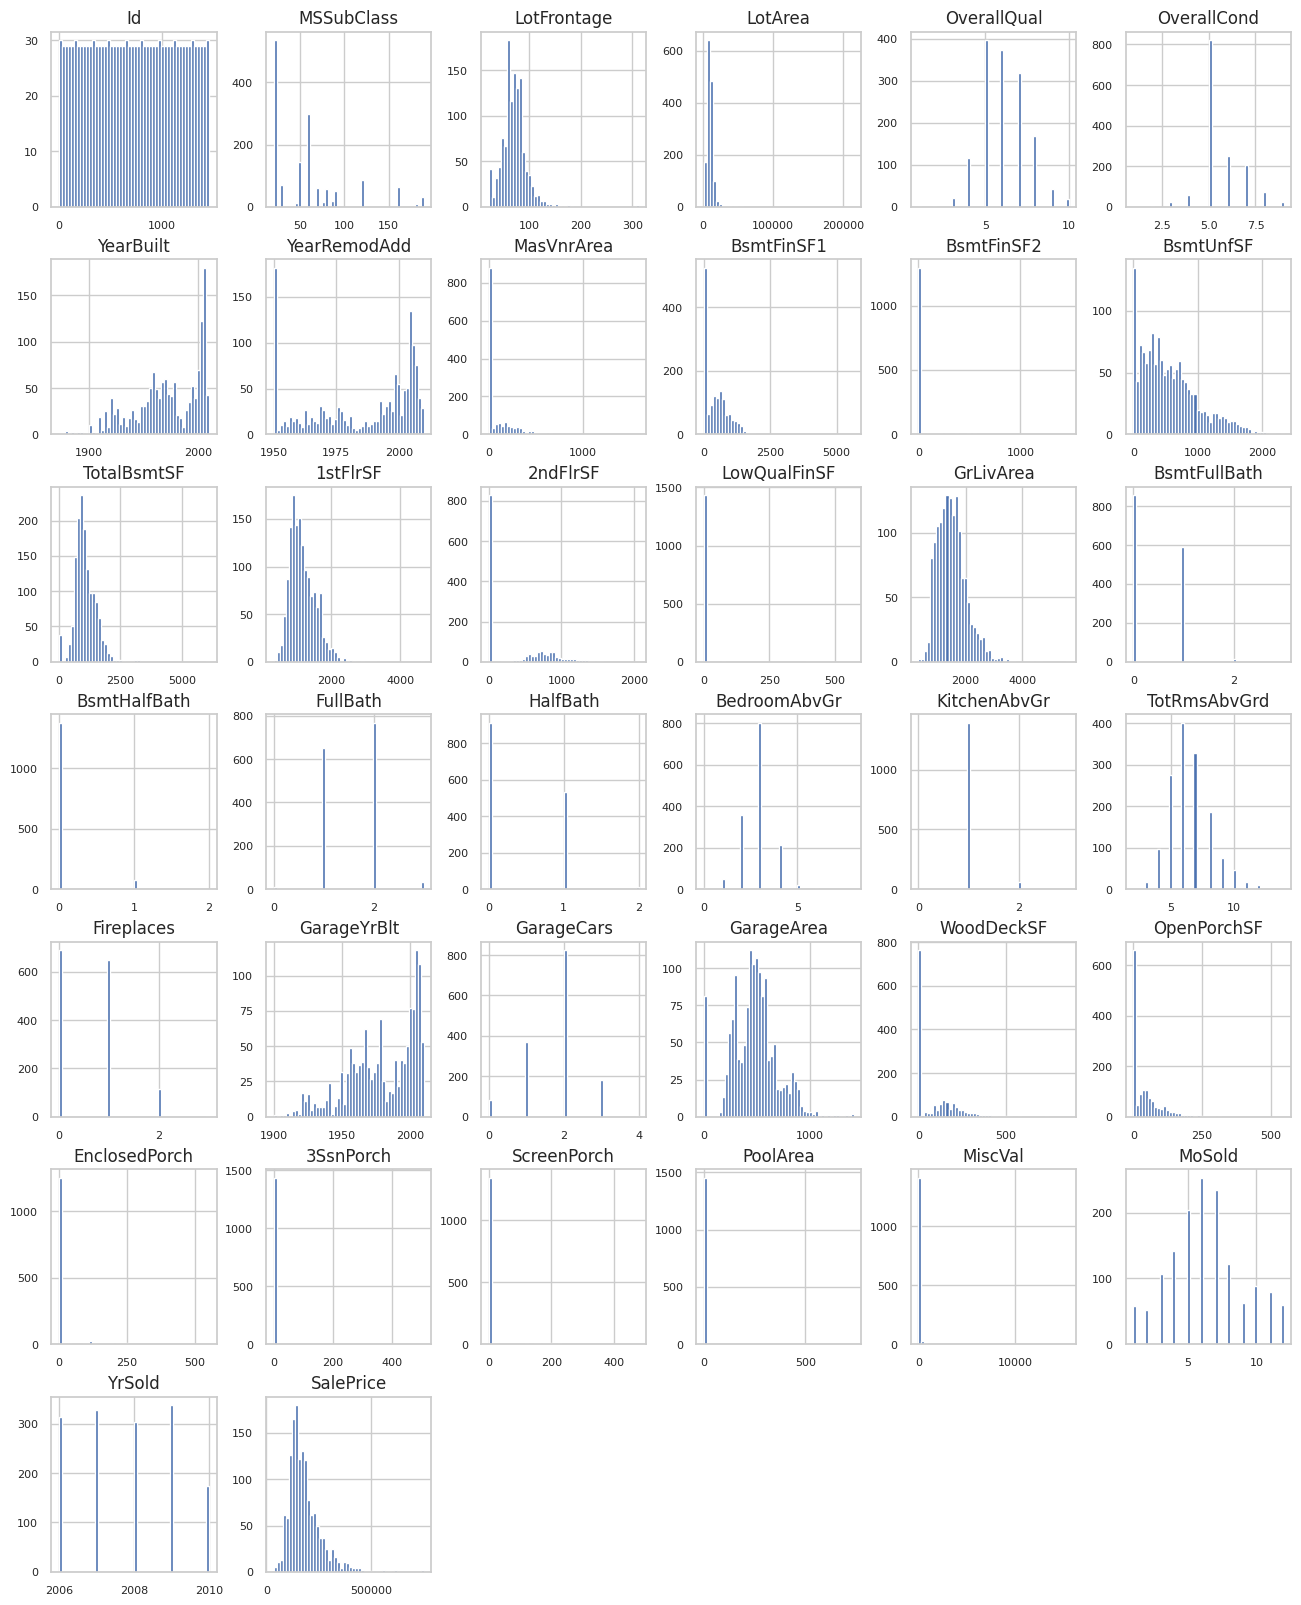

In [16]:
numeric_features.hist(figsize=(16,20) , bins = 50 , xlabelsize = 8  ,ylabelsize = 8);

<Axes: >

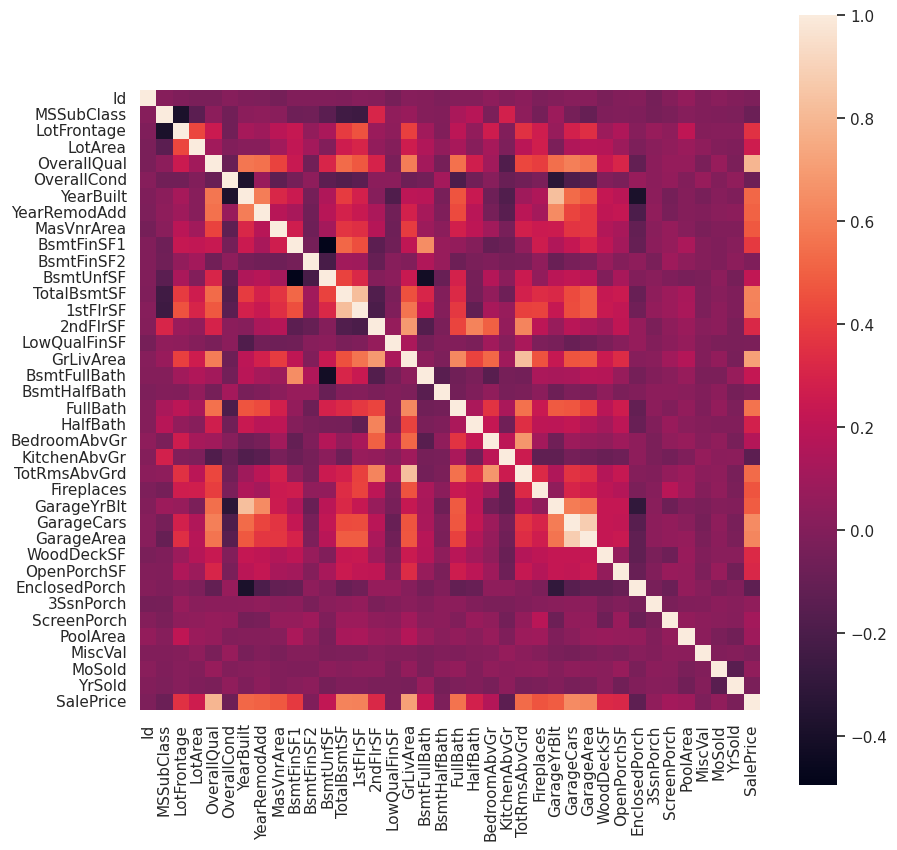

In [17]:
plt.figure(figsize=(10,10))
sns.heatmap(numeric_features.corr() ,square=True)

<Axes: >

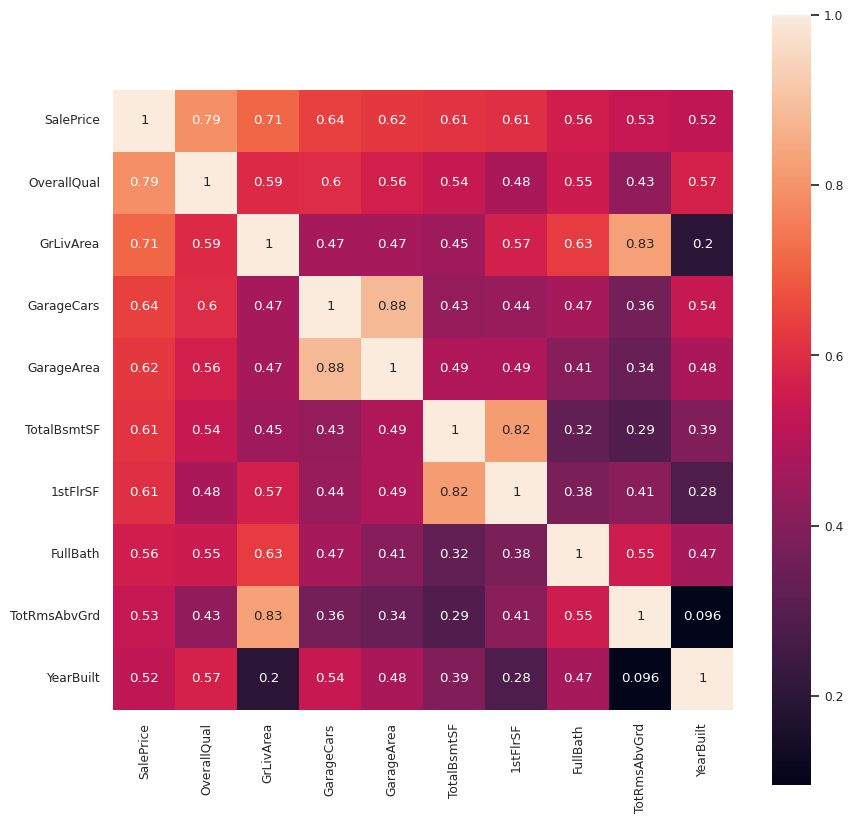

In [18]:
corrmat = numeric_features.corr()
k = 10
cols = corrmat.nlargest(k , 'SalePrice').index
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(numeric_features[cols].corr() , square=True , annot=True)

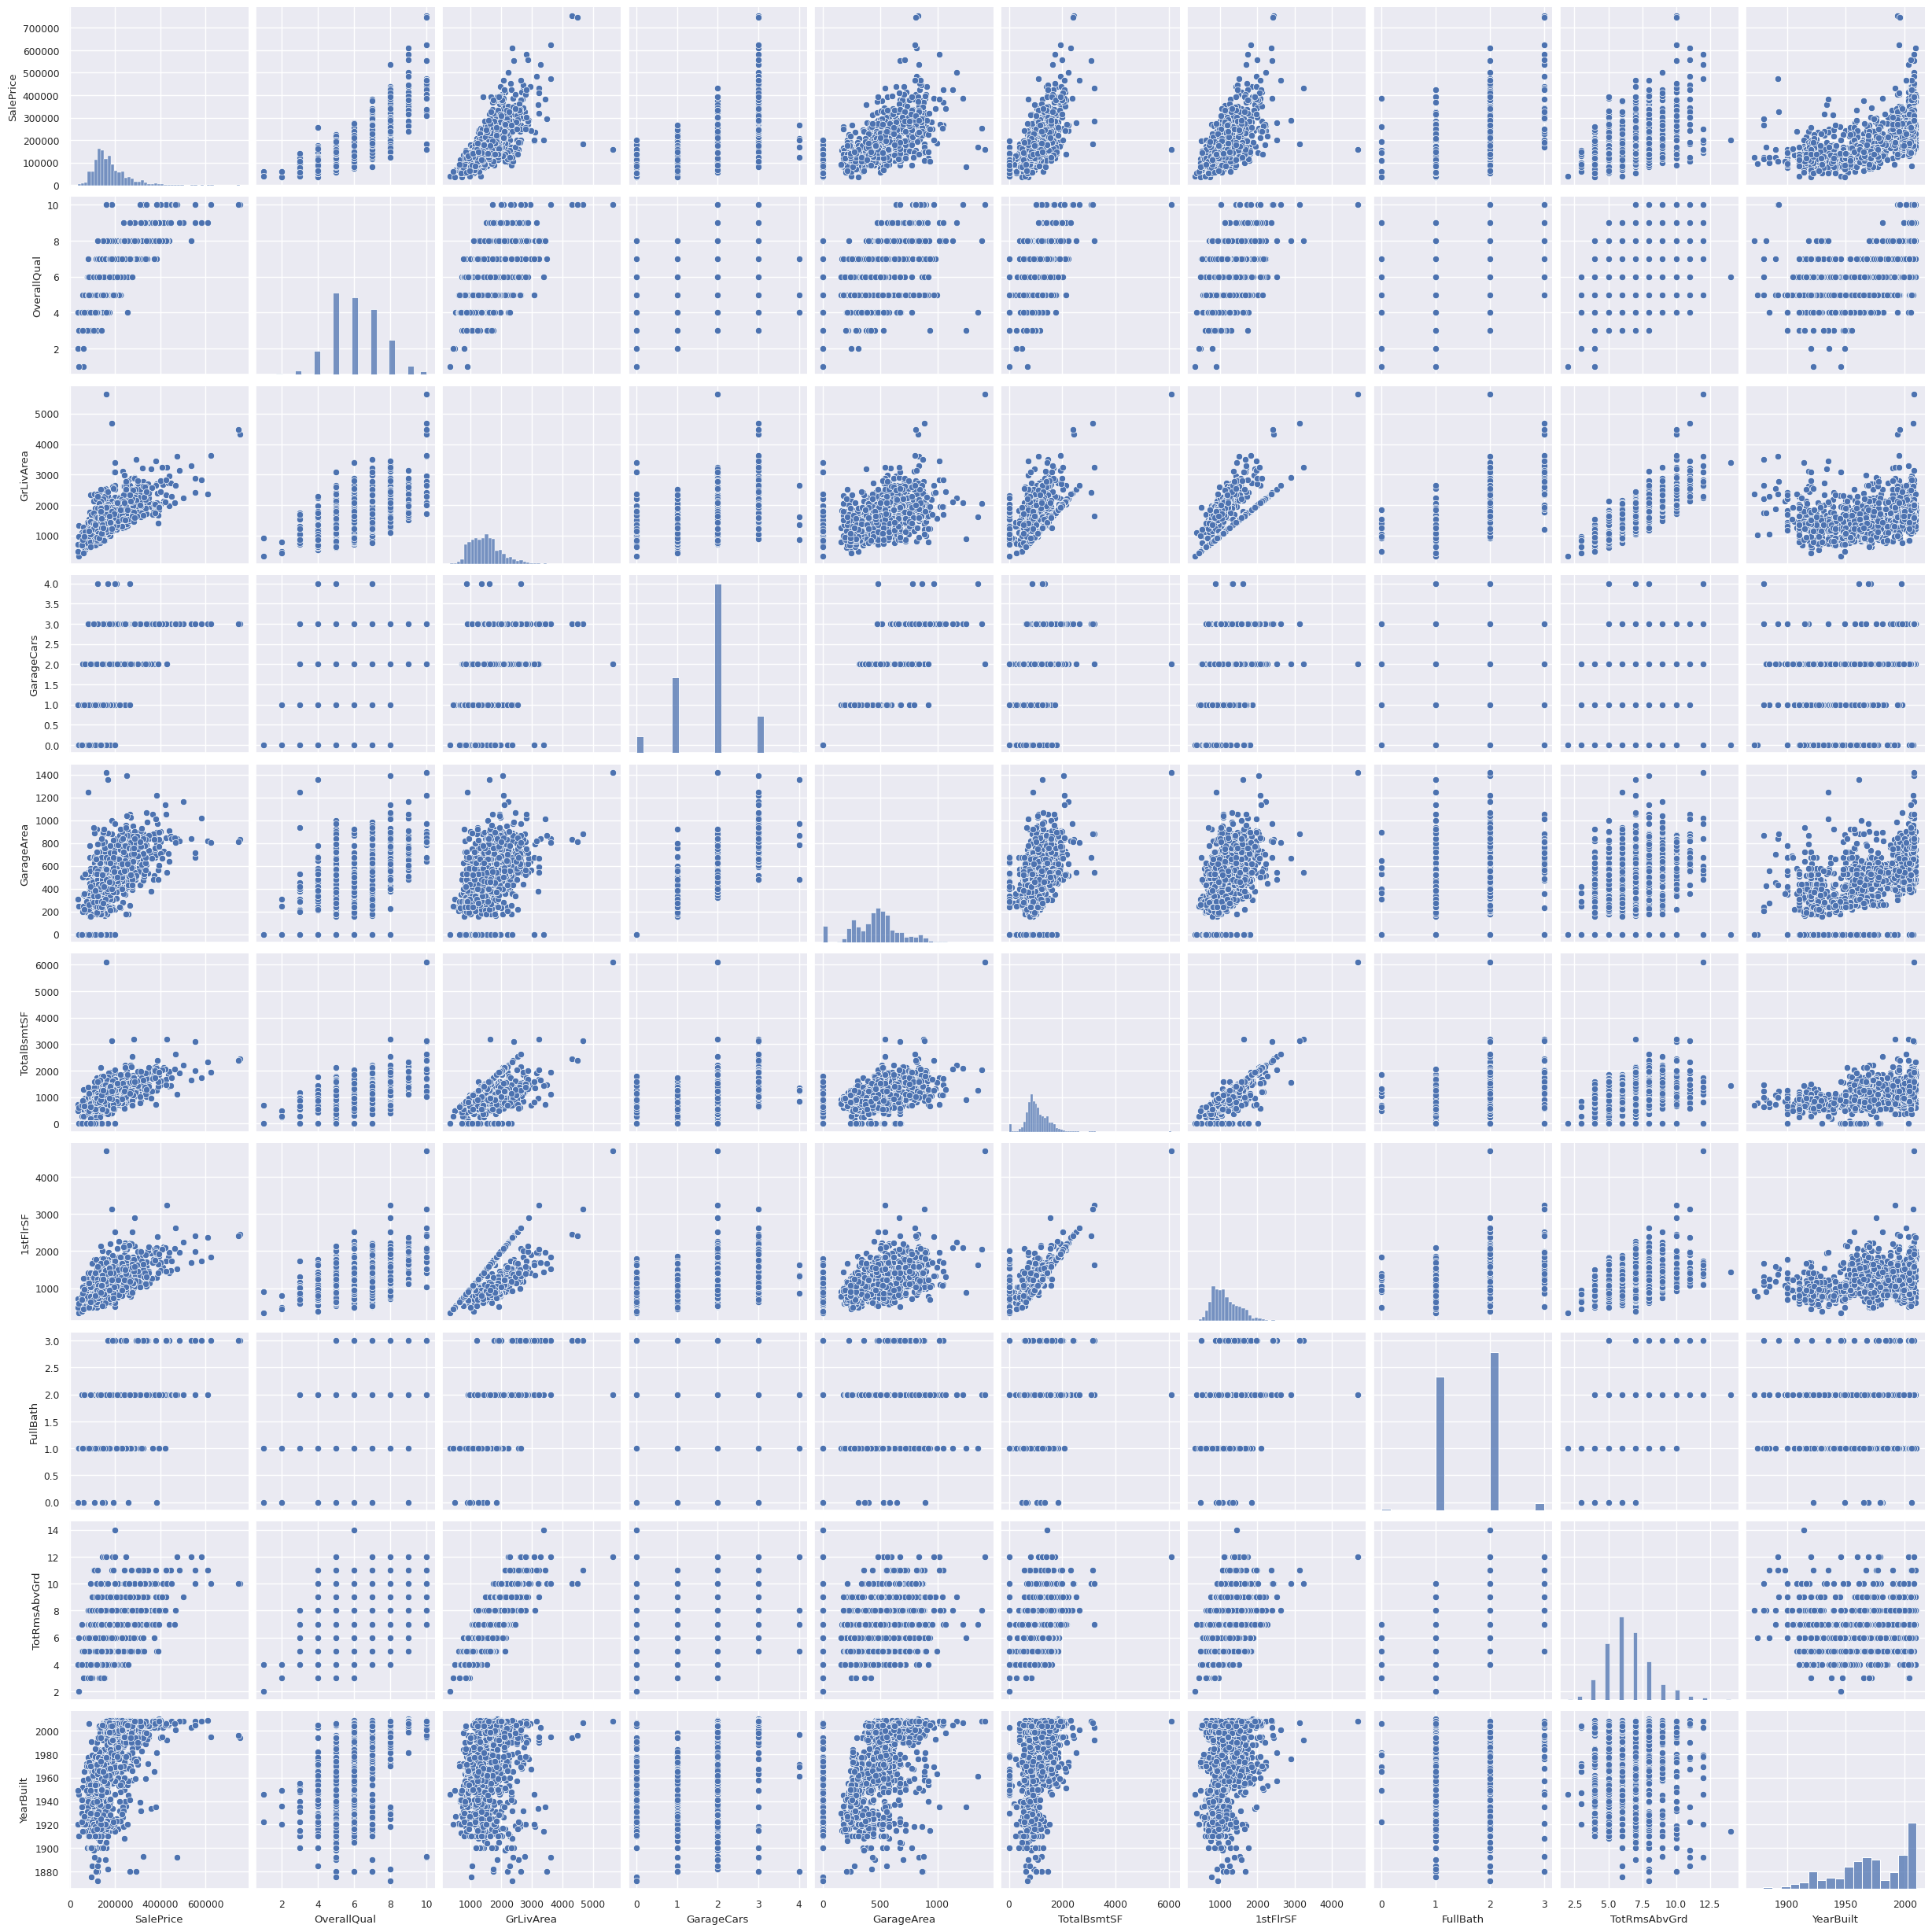

In [19]:
sns.pairplot(numeric_features[cols])

In [20]:
# missing data
total=df_train.isnull().sum().sort_values(ascending=False)
percentage = df_train.isnull().mean().sort_values(ascending=False)*100
missing_data = pd.concat([total , percentage] , axis=1 , keys=['Total' , 'Percentage'])
missing_data.head(20)

,Total,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


In [21]:
df_train = df_train.drop(missing_data[missing_data['Total'] > 1].index , axis=1)

In [22]:
df_train

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageCars,GarageArea,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,706,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,2,548,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,TA,TA,CBlock,978,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,2,460,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,486,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,2,608,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,TA,TA,BrkTil,216,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,3,642,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,655,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,3,836,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,0,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,2,460,Y,0,40,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,TA,TA,CBlock,790,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,2,500,Y,349,0,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,Ex,Gd,Stone,275,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,1,252,Y,0,60,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,TA,TA,CBlock,49,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,1,240,Y,366,0,112,0,0,0,0,4,2010,WD,Normal,142125


In [23]:
df_train = df_train.dropna()

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

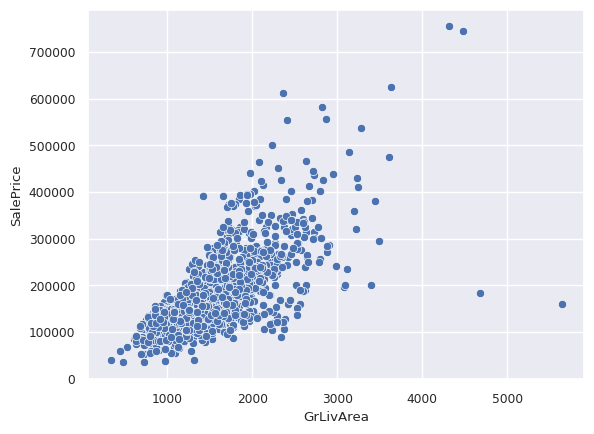

In [24]:
sns.scatterplot(data = df_train , x = 'GrLivArea' , y = 'SalePrice')

In [25]:
df_train = df_train.drop(df_train[df_train['Id'] == 1299].index)
df_train = df_train.drop(df_train[df_train['Id'] == 524].index)

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

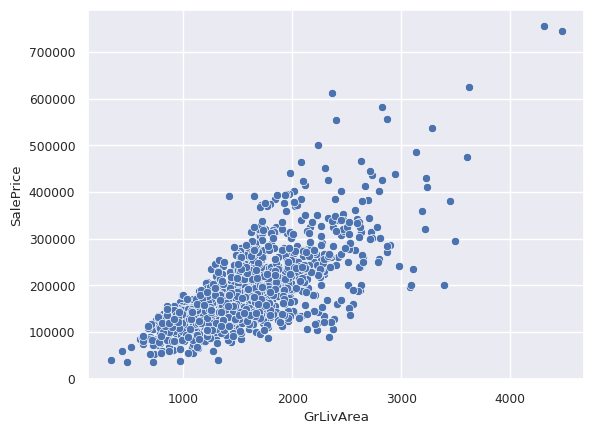

In [26]:
sns.scatterplot(data = df_train , x = 'GrLivArea' , y = 'SalePrice')

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

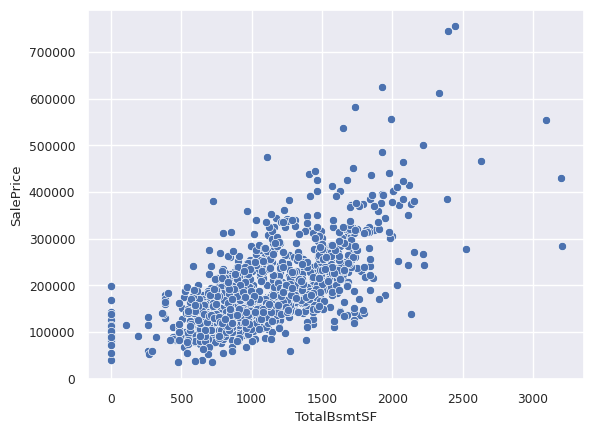

In [27]:
sns.scatterplot(data = df_train , x = 'TotalBsmtSF' , y = 'SalePrice')

<Axes: xlabel='SalePrice', ylabel='Density'>

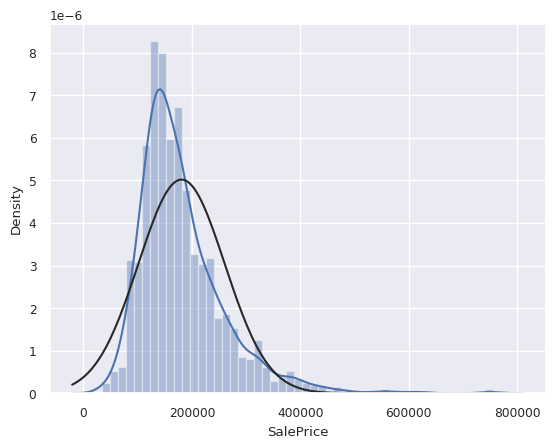

In [28]:
sns.distplot( df_train['SalePrice'], fit=norm)

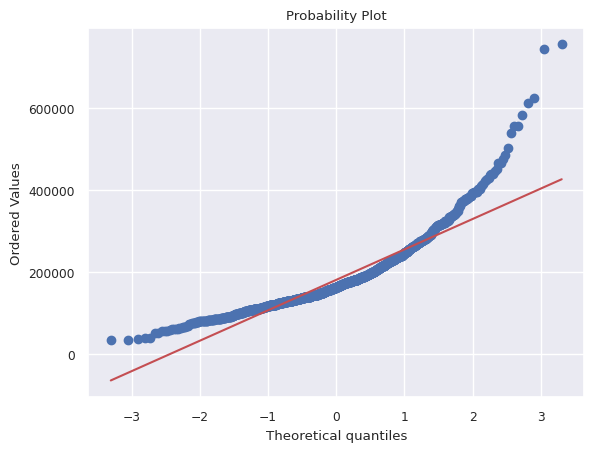

In [29]:
stats.probplot(df_train['SalePrice'] , plot = plt);

In [30]:
df_train['SalePrice'] = np.log(df_train['SalePrice'])

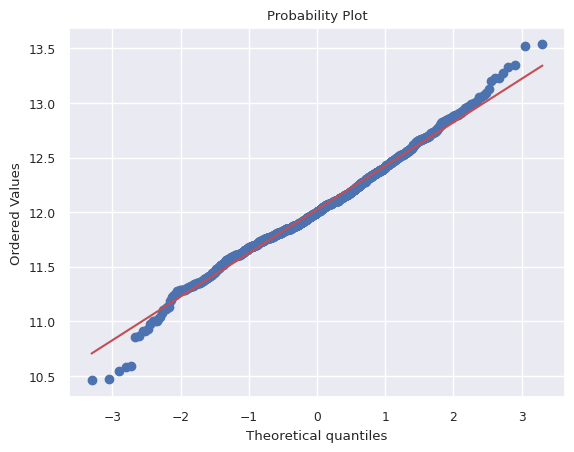

In [31]:
stats.probplot(df_train['SalePrice'] , plot = plt);

<Axes: xlabel='SalePrice', ylabel='Density'>

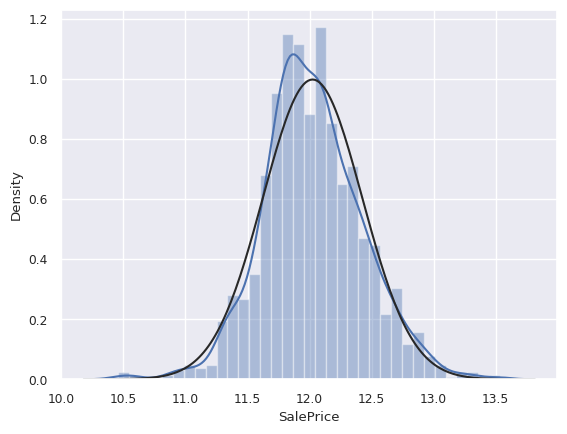

In [32]:
sns.distplot( df_train['SalePrice'], fit=norm)

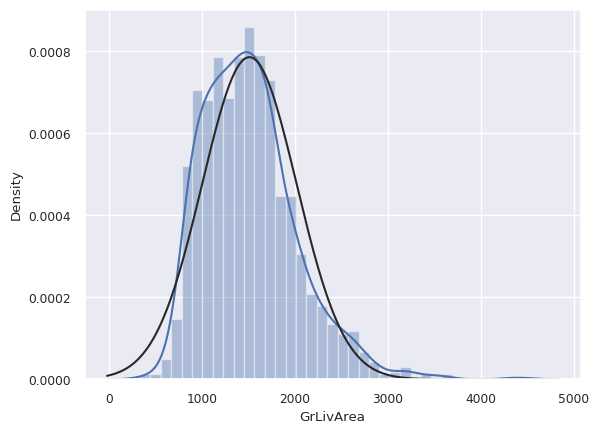

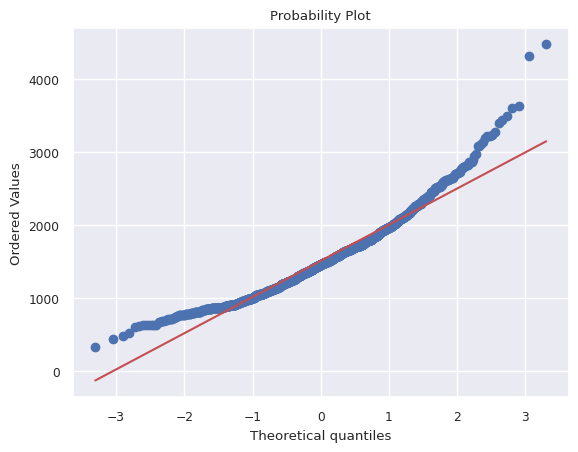

In [33]:
sns.distplot(df_train['GrLivArea'] , fit=norm);
plt.show()
stats.probplot(df_train['GrLivArea'] , plot = plt);

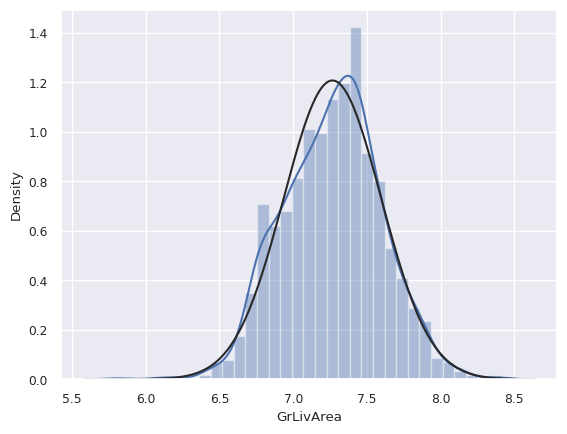

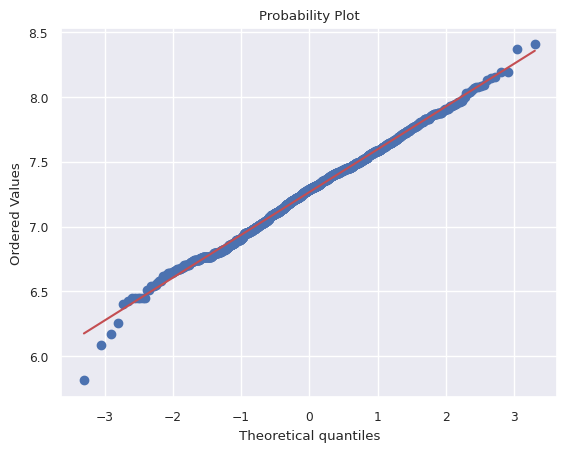

In [34]:
#data transformation
df_train['GrLivArea'] = np.log(df_train['GrLivArea'])
sns.distplot(df_train['GrLivArea'] , fit=norm);
plt.show()
stats.probplot(df_train['GrLivArea'] , plot = plt);

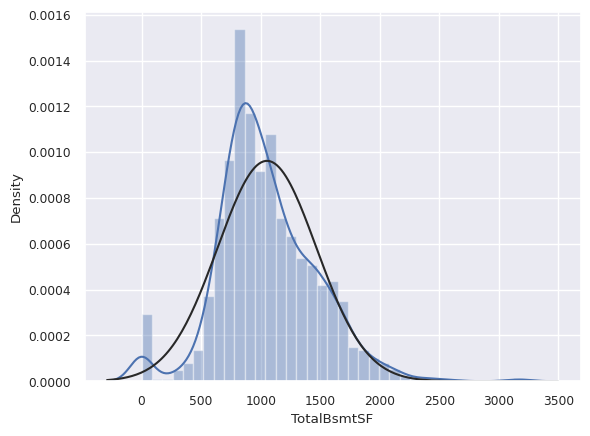

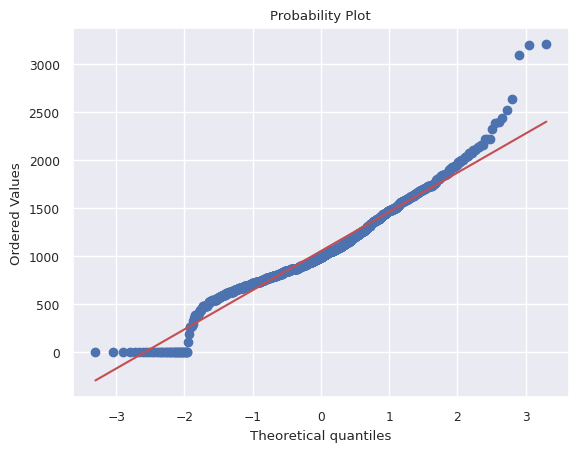

In [35]:
sns.distplot(df_train['TotalBsmtSF'] , fit=norm);
plt.show()
stats.probplot(df_train['TotalBsmtSF'] , plot = plt);

In [36]:
df_train.loc[df_train['TotalBsmtSF'] > 0 , ['TotalBsmtSF']] = np.log(df_train.loc[df_train['TotalBsmtSF'] > 0 , ['TotalBsmtSF']])

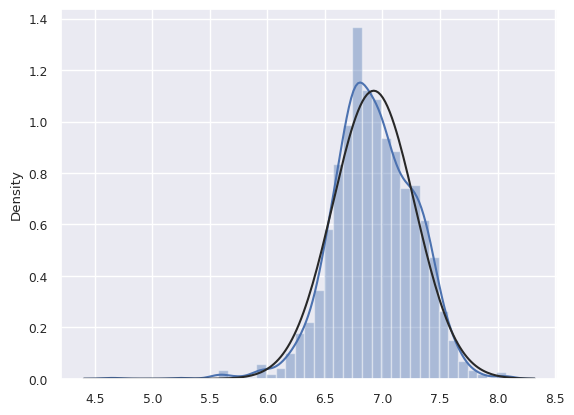

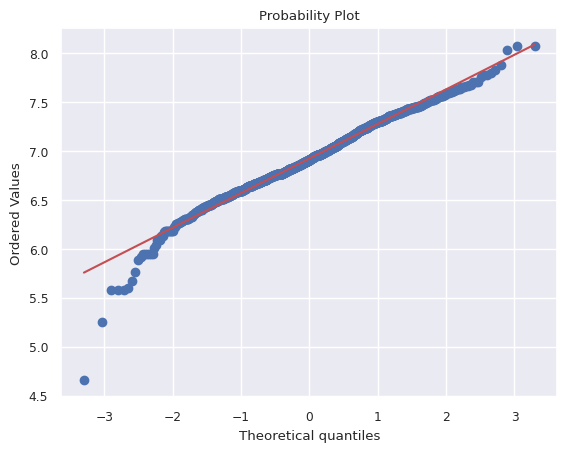

In [37]:
sns.distplot(df_train.loc[df_train['TotalBsmtSF'] > 0 , ['TotalBsmtSF']] , fit=norm);
plt.show()
stats.probplot(df_train.loc[df_train['TotalBsmtSF'] > 0 ]['TotalBsmtSF'] , plot = plt);

In [38]:
pd.get_dummies(df_train)
df_train.drop('Id', axis=1 , inplace=True)
df_train = pd.get_dummies(df_train)

In [39]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(
    df_train.drop('SalePrice' , axis = 1),
    df_train['SalePrice'],
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train , y_train)
rf.score(X_test , y_test)

0.8846462676972352

In [41]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=150)
gb.fit(X_train , y_train)
gb.score(X_test , y_test)

0.9169549894194086

In [42]:
from sklearn.ensemble import AdaBoostRegressor
ada = AdaBoostRegressor(n_estimators=500)
ada.fit(X_train , y_train)
ada.score(X_test , y_test)

0.835466157108774

In [43]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators = 2000 , learning_rate=0.05)
xgb.fit(X_train , y_train)
xgb.score(X_test , y_test)

0.8923322831555291

In [44]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test , gb.predict(X_test))

0.12003918738100125

In [45]:
df_train.isnull().sum() > 0

MSSubClass               False
LotArea                  False
OverallQual              False
OverallCond              False
YearBuilt                False
                         ...  
SaleCondition_AdjLand    False
SaleCondition_Alloca     False
SaleCondition_Family     False
SaleCondition_Normal     False
SaleCondition_Partial    False
Length: 220, dtype: bool